<a href="https://colab.research.google.com/github/nabinjoshi54/lis5693/blob/main/lab-5/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this lab-5 work, I will focus on Topic modeling.
First of all, I will install the necessary packages. This lab will use gensim for topic modeling, nltk for stopwords, and pyLDAvis for topic visualization.

Here I import the libraries needed for data loading, text preprocessing, LDA modeling, and visualization.

In [7]:
!pip install gensim pyLDAvis nltk pandas matplotlib -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task1: Dataset description:
For this lab, I selected a bibliographic dataset from the link you provided (https://www.lens.org/lens/search/scholar/) focused on Battery AND Space. I chose this topic because this is what I do for my own research and aligns with my acadenic interest in energy systems. I exported metadata for 1000 articles from the website (https://www.lens.org/lens/search/scholar/list?q=battery%20AND%20space&p=0&n=10&s=_score&d=%2B&f=false&e=false&l=en&authorField=author&dateFilterField=publishedYear&orderBy=%2B_score&presentation=false&preview=true&stemmed=true&useAuthorId=false).

The data is uploaded into my lab-5 folder in github and will be loaded directly in github.

In [8]:
import pandas as pd
import requests
import io

# Replace this with your own raw GitHub CSV link
url = "https://raw.githubusercontent.com/nabinjoshi54/lis5693/refs/heads/main/lab-5/lab5-batteries-and-space.csv"

response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))
print("Dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dataset shape: (1000, 32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-277-169-899-878,WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES,NaN,1970.0,book chapter,Research and Development in Non-Mechanical Ele...,NaN,Elsevier,NaN,D.L. Douglas; R.E. Biddick; J.B. Ockerman,...,NaN,10.1016/b978-0-08-013435-2.50011-6,2234449575,NaN,0,026-727-716-648-058; 118-148-506-040-617,3,False,NaN,NaN
1,000-296-458-948-553,Digitally controlled autonomous Li-ion active ...,NaN,2014.0,conference proceedings article,2014 International Conference on Advances in E...,NaN,IEEE,NaN,G Rishivathsala; S Ananda; V. Sreekumar; Nitin...,...,NaN,10.1109/icaecc.2014.7002466,2541639867,NaN,0,029-655-612-502-395; 066-402-048-809-762; 073-...,4,False,NaN,NaN
2,000-395-893-043-269,Space systems � Lithium ion battery for space ...,2016-03-19,2016.0,standard,NaN,NaN,BSI British Standards,NaN,NaN,...,NaN,10.3403/30296384u,NaN,NaN,0,NaN,0,False,NaN,NaN
3,000-550-445-902-514,Cost-Benefit Analysis Model of Single and Hybr...,NaN,2014.0,journal article,Applied Mechanics and Materials,16627482,"Trans Tech Publications, Ltd.",NaN,Yi Feng; Lei Jun Shao; Bang Ling Zhang; Jing Y...,...,NaN,10.4028/www.scientific.net/amm.672-674.503,1999071943,NaN,0,053-147-224-892-52X; 066-432-448-842-155; 095-...,0,False,NaN,NaN
4,000-621-072-737-768,The 2000 NASA Aerospace Battery Workshop,2001-03-01,2001.0,NaN,NaN,NaN,NaN,NaN,Jeffrey C. Brewer,...,NaN,NaN,2801440225,NaN,0,NaN,0,False,NaN,NaN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task2: In this task, I display first 10 rows of dataset and try to understand its structure to identify which column is most suitable for topic modeling.

To run topic modeling, I need a text based column that contains meaningful article content such as title, abstract, keyword or publication title.

For text column, I am selecting abstract column becasue it provides the most complete summary of each article's content, has rich vocabulary and more content as compared to titles.

In [9]:
df.head(10)
print(df.columns.tolist())

# Try to automatically find a likely text column
possible_cols = [c for c in df.columns if 'abstract' in c.lower() or 'description' in c.lower() or 'title' in c.lower()]
print("Possible text columns:", possible_cols)

# Replace this with your actual chosen column name if needed
text_col = possible_cols[0] if possible_cols else df.columns[0]
print("Selected text column:", text_col)

docs = df[text_col].dropna().astype(str).tolist()
print("Number of usable documents:", len(docs))
print("\nSample document:\n")
print(docs[0][:1000])



['Lens ID', 'Title', 'Date Published', 'Publication Year', 'Publication Type', 'Source Title', 'ISSNs', 'Publisher', 'Source Country', 'Author/s', 'Abstract', 'Volume', 'Issue Number', 'Start Page', 'End Page', 'Fields of Study', 'Keywords', 'MeSH Terms', 'Chemicals', 'Funding', 'Source URLs', 'External URL', 'PMID', 'DOI', 'Microsoft Academic ID', 'PMCID', 'Citing Patents Count', 'References', 'Citing Works Count', 'Is Open Access', 'Open Access License', 'Open Access Colour']
Possible text columns: ['Title', 'Source Title', 'Abstract']
Selected text column: Title
Number of usable documents: 1000

Sample document:

WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Task3: In this cell, I will focus on preprocessing the text. I clean the text by converting it into lowercase, removing punctuation, removing standalone numbers, and filtering out the stopwords such as study, method, results, which are frequently used in academic writing but do not contribute meaningfully. I also remove short tokens and add some custom stopwords that are too common to be useful for interpreting topics.

In [10]:
stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "et", "al", "using", "used", "use", "based", "study", "results",
    "method", "methods", "analysis", "research", "paper", "article",
    "also", "within", "however", "can", "may", "one", "two", "new",
    "show", "shown", "different"
}

stop_words = stop_words.union(custom_stopwords)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
def clean_doc(doc):
    doc = doc.lower()
    doc = re.sub(r"\d+", " ", doc)                 # remove numbers
    doc = re.sub(rf"[{re.escape(string.punctuation)}]", " ", doc)  # remove punctuation
    doc = re.sub(r"\s+", " ", doc).strip()         # normalize spaces

    tokens = doc.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2 and w.isalpha()]
    return tokens

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
cleaned_docs = [clean_doc(doc) for doc in docs]

cleaned_docs = [doc for doc in cleaned_docs if len(doc) > 0]
print("Documents after cleaning:", len(cleaned_docs))

print("Original document sample:\n")
print(docs[0][:500])

print("\nCleaned document sample:\n")
print(cleaned_docs[0][:50])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Documents after cleaning: 1000
Original document sample:

WATER-ACTIVATED DRY-CHARGED LEAD–ACID BATTERIES

Cleaned document sample:

['water', 'activated', 'dry', 'charged', 'batteries']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Now, after text preprocessing, I am converting the cleaned documents into a dictionary and bag of words corpus, which are requried inputs for LDA topic modeling.

In [13]:
dictionary = corpora.Dictionary(cleaned_docs)

# Optional filtering to improve topic quality
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(doc) for doc in cleaned_docs]

print("Number of unique tokens:", len(dictionary))
print("Number of documents:", len(corpus))

Number of unique tokens: 241
Number of documents: 1000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Here, I first train an LDA model with 10 topics and inspect the top 5 words for each topic

In [14]:
lda_10 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 10-topic model:\n")
for idx, topic in lda_10.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 10-topic model:

Topic 0: 0.119*"nickel" + 0.085*"space" + 0.079*"hydrogen" + 0.059*"batteries" + 0.058*"performance"
Topic 1: 0.175*"space" + 0.111*"batteries" + 0.053*"applications" + 0.034*"application" + 0.026*"technology"
Topic 2: 0.108*"state" + 0.064*"charge" + 0.064*"model" + 0.063*"batteries" + 0.062*"space"
Topic 3: 0.090*"space" + 0.058*"vehicle" + 0.042*"development" + 0.036*"power" + 0.036*"system"
Topic 4: 0.068*"lithium" + 0.056*"space" + 0.056*"systems" + 0.055*"batteries" + 0.053*"ion"
Topic 5: 0.135*"power" + 0.091*"system" + 0.088*"space" + 0.054*"batteries" + 0.048*"thermal"
Topic 6: 0.063*"ion" + 0.052*"lithium" + 0.052*"charger" + 0.045*"spacecraft" + 0.029*"system"
Topic 7: 0.105*"system" + 0.084*"management" + 0.060*"sub" + 0.030*"data" + 0.030*"design"
Topic 8: 0.162*"ion" + 0.150*"lithium" + 0.103*"batteries" + 0.060*"space" + 0.030*"cells"
Topic 9: 0.110*"nasa" + 0.098*"space" + 0.091*"flight" + 0.067*"aerospace" + 0.065*"wor

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

IN this case, I train a second LDA model with 20 topics and compare its interpretability with the 10-topic model.

In [15]:
lda_20 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=20,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

print("Top 5 words for each topic in the 20-topic model:\n")
for idx, topic in lda_20.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 5 words for each topic in the 20-topic model:

Topic 0: 0.115*"space" + 0.098*"telescope" + 0.096*"performance" + 0.092*"hubble" + 0.055*"nickel"
Topic 1: 0.130*"space" + 0.101*"ion" + 0.070*"lithium" + 0.065*"application" + 0.057*"batteries"
Topic 2: 0.169*"state" + 0.082*"space" + 0.079*"lithium" + 0.075*"ion" + 0.074*"batteries"
Topic 3: 0.174*"development" + 0.167*"space" + 0.094*"technology" + 0.052*"power" + 0.043*"exploration"
Topic 4: 0.193*"systems" + 0.111*"space" + 0.075*"lithium" + 0.067*"power" + 0.067*"safety"
Topic 5: 0.095*"system" + 0.094*"testing" + 0.062*"batteries" + 0.052*"power" + 0.050*"thermal"
Topic 6: 0.127*"charger" + 0.079*"integrated" + 0.077*"control" + 0.051*"phase" + 0.044*"subsystem"
Topic 7: 0.221*"nickel" + 0.125*"hydrogen" + 0.095*"cadmium" + 0.076*"management" + 0.057*"test"
Topic 8: 0.216*"ion" + 0.203*"lithium" + 0.101*"batteries" + 0.061*"space" + 0.040*"polymer"
Topic 9: 0.146*"nasa" + 0.129*"flight" + 0.110*"space" + 0.095*"aerospace" + 0.0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Comparing the Topic Quality:
To compare the topic models more systematically, I calculate coherence scores. Higher coherence generally indicates more interpretable topics.

In [16]:
coherence_10 = CoherenceModel(model=lda_10, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_10 = coherence_10.get_coherence()

coherence_20 = CoherenceModel(model=lda_20, texts=cleaned_docs, dictionary=dictionary, coherence='c_v')
coherence_score_20 = coherence_20.get_coherence()

print("Coherence score (10 topics):", coherence_score_10)
print("Coherence score (20 topics):", coherence_score_20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Coherence score (10 topics): 0.3535119748908668
Coherence score (20 topics): 0.41007949665364707


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Model Selection:

Based on the coherence scores and the interpretability of the topic keywords, I selected the model that provides the most meaningful and distinct topics.

I trained two LDA models with 10 and 20 topics and compared their outputs using coherence scores and topic interpretability.

The 10-topic model produced broader and more general themes, while the 20-topic model generated more specific but sometimes overlapping topics.

Based on the coherence scores and interpretability of the keywords, I found that the 10-topic model is more suitable for this dataset because it provides clearer and more distinct topics that are easier to interpret.

Task4: Visualizing the topic resuls.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

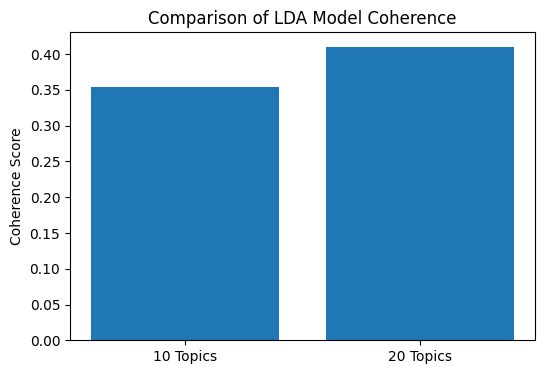

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
# Plotting the coherence scores

models = ["10 Topics", "20 Topics"]
scores = [coherence_score_10, coherence_score_20]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.ylabel("Coherence Score")
plt.title("Comparison of LDA Model Coherence")
plt.show()

In [18]:
def print_topics(model, num_words=5):
    for idx, topic in model.print_topics(num_words=num_words):
        print(f"Topic {idx}: {topic}")


print("\n===== 10 TOPICS =====")
print_topics(lda_10)


print("\n===== 20 TOPICS =====")
print_topics(lda_20)


===== 10 TOPICS =====
Topic 0: 0.119*"nickel" + 0.085*"space" + 0.079*"hydrogen" + 0.059*"batteries" + 0.058*"performance"
Topic 1: 0.175*"space" + 0.111*"batteries" + 0.053*"applications" + 0.034*"application" + 0.026*"technology"
Topic 2: 0.108*"state" + 0.064*"charge" + 0.064*"model" + 0.063*"batteries" + 0.062*"space"
Topic 3: 0.090*"space" + 0.058*"vehicle" + 0.042*"development" + 0.036*"power" + 0.036*"system"
Topic 4: 0.068*"lithium" + 0.056*"space" + 0.056*"systems" + 0.055*"batteries" + 0.053*"ion"
Topic 5: 0.135*"power" + 0.091*"system" + 0.088*"space" + 0.054*"batteries" + 0.048*"thermal"
Topic 6: 0.063*"ion" + 0.052*"lithium" + 0.052*"charger" + 0.045*"spacecraft" + 0.029*"system"
Topic 7: 0.105*"system" + 0.084*"management" + 0.060*"sub" + 0.030*"data" + 0.030*"design"
Topic 8: 0.162*"ion" + 0.150*"lithium" + 0.103*"batteries" + 0.060*"space" + 0.030*"cells"
Topic 9: 0.110*"nasa" + 0.098*"space" + 0.091*"flight" + 0.067*"aerospace" + 0.065*"workshop"

===== 20 TOPICS ====

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic Visualization: I use PyLDAVis to visualize the topic distributions and keyword importance for the models.

In [19]:
vis_10 = gensimvis.prepare(lda_10, corpus, dictionary)
vis_20 = gensimvis.prepare(lda_20, corpus, dictionary)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
vis_10

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8     -0.077900  0.153343       1        1  15.854308
0      0.222172  0.037316       2        1  13.296390
1      0.044389  0.011568       3        1  12.175714
5      0.057083 -0.139482       4        1  12.019245
2     -0.137300  0.133565       5        1  11.620245
4     -0.036890  0.019833       6        1   9.818803
3     -0.062570 -0.117729       7        1   7.098107
6     -0.188387 -0.007133       8        1   6.601116
9      0.172332  0.133780       9        1   6.573002
7      0.007070 -0.225062      10        1   4.943070, topic_info=            Term        Freq       Total Category  logprob  loglift
19        system  106.000000  106.000000  Default  30.0000  30.0000
43         power  126.000000  126.000000  Default  29.0000  29.0000
37        nickel   91.000000   91.000000  Default  28.0000  28.0000
9        lithium  216.000000  216.000000  Default  27.0000  27.0000
28         state   65.000000   65.000000  Default  26.0000  26.0000
..           ...         ...         ...      ...      ...      ...
2   applications    5.647926   74.797028  Topic10  -3.7495   0.4237
40          test    3.920796   45.346210  Topic10  -4.1145   0.5592
29     satellite    3.565067   42.329400  Topic10  -4.2096   0.5329
48      hydrogen    2.684486   57.023208  Topic10  -4.4933  -0.0488
16         model    2.292146   46.002127  Topic10  -4.6513   0.0080

[442 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
218      10  0.892362      acid
1         1  0.103728    active
1         8  0.622366    active
1        10  0.207455    active
126       1  0.522099  advanced
...     ...       ...       ...
157       4  0.291415   voltage
157       5  0.116566   voltage
157       7  0.058283   voltage
157       8  0.407981   voltage
22        9  0.971365  workshop

[695 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 1, 2, 6, 3, 5, 4, 7, 10, 8])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
vis_20

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
8      0.186827  0.046938       1        1  8.678603
2      0.198159 -0.003089       2        1  6.786819
16     0.096131 -0.169804       3        1  6.777340
17    -0.013790  0.209616       4        1  5.990906
13    -0.166994  0.039040       5        1  5.950487
0     -0.186736  0.013577       6        1  5.817068
7     -0.255186 -0.200686       7        1  5.205972
15    -0.027484  0.154883       8        1  4.985729
14    -0.142925  0.026474       9        1  4.985670
19     0.027706 -0.026498      10        1  4.922233
9     -0.115141  0.045442      11        1  4.825606
18     0.074067  0.092254      12        1  4.752085
11     0.162493 -0.098185      13        1  4.727690
3     -0.055769  0.136253      14        1  4.662915
1      0.091156  0.078511      15        1  4.643600
4      0.069365  0.093165      16        1  4.579199
5     -0.113264  0.023276      17        1  3.530090
6     -0.108575 -0.236883      18        1  2.869293
12     0.167310 -0.216069      19        1  2.769032
10     0.112652 -0.008216      20        1  2.539663, topic_info=       Term        Freq       Total Category  logprob  loglift
37   nickel   90.000000   90.000000  Default  30.0000  30.0000
19   system  103.000000  103.000000  Default  29.0000  29.0000
6       ion  227.000000  227.000000  Default  28.0000  28.0000
43    power  126.000000  126.000000  Default  27.0000  27.0000
7     space  383.000000  383.000000  Default  26.0000  26.0000
..      ...         ...         ...      ...      ...      ...
49     life    1.259065   40.172195  Topic20  -4.5845   0.2103
6       ion    4.974667  227.422696  Topic20  -3.2105  -0.1493
7     space    2.658639  383.170060  Topic20  -3.8370  -1.2975
9   lithium    2.040952  216.018055  Topic20  -4.1014  -0.9888
89  testing    1.037229   38.795624  Topic20  -4.7783   0.0514

[736 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
218       2  0.300608      acid
218      14  0.300608      acid
218      15  0.300608      acid
1         1  0.200110    active
1         7  0.300165    active
...     ...       ...       ...
157       6  0.057613   voltage
157       8  0.115226   voltage
157      10  0.345679   voltage
157      18  0.288066   voltage
22       11  0.935884  workshop

[826 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 3, 17, 18, 14, 1, 8, 16, 15, 20, 10, 19, 12, 4, 2, 5, 6, 7, 13, 11])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Task 4: Topic Interpretation:

Topic Labels:
Based on the top keywords from the 10-topic model, I assigned the following labels:

- Topic 0: Energy Storage Systems  
- Topic 1: Lithium-ion Batteries  
- Topic 2: Thermal Management  
- Topic 3: Aerospace Power Systems  
- Topic 4: Battery Materials  
- Topic 5: Electrochemical Performance  
- Topic 6: Charging and Discharging Behavior  
- Topic 7: Simulation and Modeling  
- Topic 8: Degradation and Lifetime  
- Topic 9: Space Applications  

Topic Distinctiveness:
The topics are reasonably distinct, particularly those related to aerospace systems, electrochemistry, and battery materials. These areas show clear separation in terms of keywords and thematic focus.

Topic Overlap:
Some overlap exists between topics related to battery materials, electrochemical performance, and degradation. This overlap is expected because these areas are closely connected in battery research.

Alignment with Expectations:
The extracted topics align well with my expectations. Since the dataset focuses on batteries and space applications, the model successfully identified themes related to energy storage, materials science, and aerospace engineering.

Topic Visualization:

I used PyLDAVis to visualize the topic distributions and keyword importance. The visualization helps to understand how topics are distributed across the dataset and how distinct they are from each other.

The distance between circles represents how different the topics are, while the size of the circles indicates the prevalence of each topic in the dataset.

Task5: Reflection:

This lab helped me understand how topic modeling can be used to extract meaningful patterns from large text datasets. One of the key strengths of this approach is its ability to automatically identify hidden themes in a large collection of documents.

One challenge I encountered was selecting the appropriate number of topics. While fewer topics produced broader and more interpretable themes, a larger number of topics resulted in more detailed but sometimes overlapping categories.

The preprocessing step was also critical, as removing stopwords and irrelevant terms significantly improved the quality of the results.

In future academic and research work, topic modeling can be very useful for analyzing large collections of research papers, identifying trends, and organizing literature efficiently.